In [1]:
import os
import pickle
import numpy as np
import cv2
from tqdm import tqdm
import matplotlib.pyplot as plt
from utils.data_loader import RainfallDataLoader
from mpl_toolkits.axes_grid1 import make_axes_locatable
import rasterio
from scipy import ndimage
from scipy.spatial.distance import cdist
import geopandas as gpd
from shapely.geometry import Point
import warnings
from PIL import Image
import statsmodels.api as sm
# warnings.filterwarnings('ignore')

### Loading Data

In [2]:
rainfall_data_loader = RainfallDataLoader()

chirps_data_dict = rainfall_data_loader.get_chirps_data()
chirps_dates = list(chirps_data_dict.keys())
chirps_dates = np.array(chirps_dates)
chirps_dataset = np.array(list(chirps_data_dict.values()))

original_era5_data_dict, reprojected_era5_data_dict = rainfall_data_loader.get_era5_data()

era5_dates = list(original_era5_data_dict.keys())
original_era5_dataset = list(original_era5_data_dict.values())
reprojected_era5_dataset = list(reprojected_era5_data_dict.values())
era5_dates = np.array(era5_dates)
original_era5_dataset = np.array(original_era5_dataset)
reprojected_era5_dataset = np.array(reprojected_era5_dataset)

Loading ERA5 Data: 100%|██████████| 14435/14435 [00:00<00:00, 4646924.42it/s]


In [3]:
reprojected_era5_dataset[:,2,:].min()

np.float32(-19.034811)

### Creating fake extreme events similar to extreme events in data

480.80164
Found 2 extreme events in data


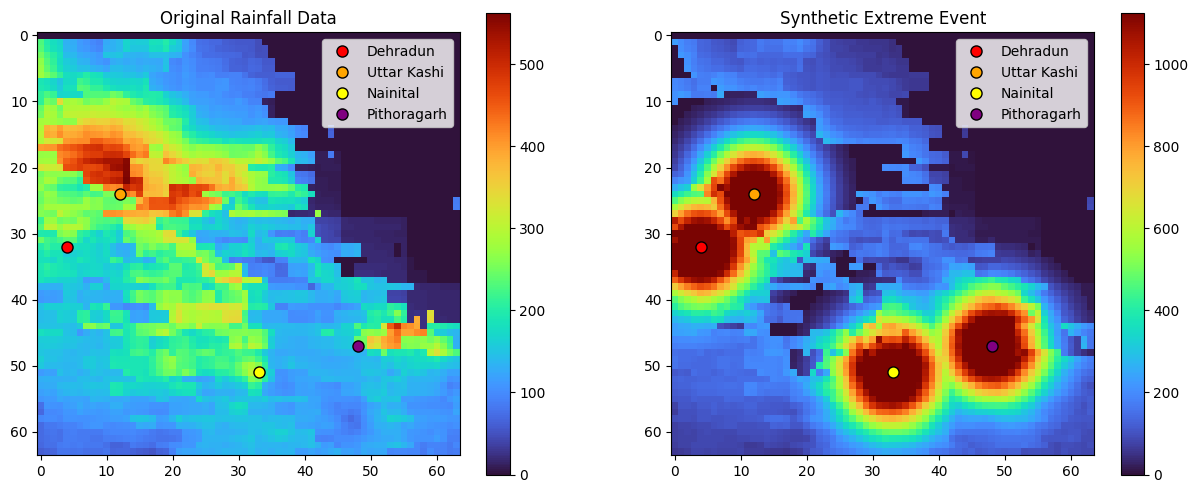

Original data - Max: 562.76, Mean: 144.22
Synthetic event - Max: 1125.52, Mean: 109.86


In [4]:
class ExtremeRainfallGenerator:
    def __init__(self, rainfall_raster_path):
        """
        Initialize with base rainfall data
        
        Parameters:
        rainfall_raster_path: path to your rainfall raster file
        """
        self.src = rasterio.open(rainfall_raster_path)
        self.rainfall_data = self.src.read(1)
        self.rainfall_data[np.isnan(self.rainfall_data)] = 0.0
        self.rainfall_data[self.rainfall_data < 0.1] = 0.0
        self.profile = self.src.profile
        
    def extract_extreme_events(self, threshold_percentile=95, min_event_size=10):
        """
        Extract extreme rainfall events from existing data
        
        Parameters:
        threshold_percentile: percentile threshold for extreme events
        min_event_size: minimum contiguous area for an event
        """
        # Calculate threshold
        threshold = np.percentile(self.rainfall_data, threshold_percentile)
        print(threshold)
        # Create binary mask for extreme events
        extreme_mask = self.rainfall_data > threshold
        
        # Label connected components
        labeled_array, num_features = ndimage.label(extreme_mask)
        
        extreme_events = []
        for i in range(1, num_features + 1):
            event_mask = labeled_array == i
            if np.sum(event_mask) >= min_event_size:
                # Extract event properties
                event_indices = np.where(event_mask)
                event_values = self.rainfall_data[event_mask]
                
                event_properties = {
                    'mask': event_mask,
                    'values': event_values,
                    'centroid': self._calculate_centroid(event_indices),
                    'intensity_stats': {
                        'mean': np.mean(event_values),
                        'max': np.max(event_values),
                        'std': np.std(event_values)
                    },
                    'size': np.sum(event_mask)
                }
                extreme_events.append(event_properties)
        
        return extreme_events
    
    def _calculate_centroid(self, indices):
        """Calculate centroid of event from indices"""
        rows, cols = indices
        return np.mean(rows), np.mean(cols)
    
    def create_synthetic_event(self, key_area_coords, event_template=None, 
                             intensity_factor=1.5, size_factor=1.0, 
                             blend_with_background=True):
        """
        Create a synthetic extreme rainfall event
        
        Parameters:
        key_area_coords: list of (x, y) coordinates for key areas
        event_template: template event from extract_extreme_events (optional)
        intensity_factor: multiplier for rainfall intensity
        size_factor: multiplier for event size
        blend_with_background: whether to blend with background rainfall
        """
        
        # Convert geographic coordinates to pixel coordinates
        pixel_coords = []
        for coord in key_area_coords.values():
            py, px = self.src.index(coord[0], coord[1])
            pixel_coords.append((px, py))
        
        # Create base synthetic event
        if event_template is None:
            synthetic_event = self._create_default_event(pixel_coords, 
                                                        intensity_factor, 
                                                        size_factor)
        else:
            synthetic_event = self._create_event_from_template(event_template, 
                                                              pixel_coords,
                                                              intensity_factor,
                                                              size_factor)
        
        # Blend with background if requested
        if blend_with_background:
            background = self._get_background_rainfall()
            synthetic_event = self._blend_with_background(synthetic_event, background)
        
        return synthetic_event
    
    def _create_default_event(self, pixel_coords, intensity_factor, size_factor):
        """Create a default extreme event pattern"""
        rows, cols = self.rainfall_data.shape
        synthetic_event = np.zeros((rows, cols))
        
        for center_x, center_y in pixel_coords:
            # Create distance grid from center
            y, x = np.ogrid[:rows, :cols]
            distance = np.sqrt((x - center_x)**2 + (y - center_y)**2)
            
            # Define event radius based on size factor
            radius = 20 * size_factor  # base radius in pixels
            
            # Create Gaussian-like rainfall pattern
            event_mask = distance <= radius
            intensity = np.exp(-distance**2 / (2 * (radius/3)**2))
            
            # Scale intensity
            max_intensity = np.percentile(self.rainfall_data, 99) * intensity_factor
            intensity = intensity * max_intensity
            
            # Add to synthetic event
            synthetic_event[event_mask] = np.maximum(synthetic_event[event_mask], 
                                                   intensity[event_mask])
        
        return synthetic_event
    
    def _create_event_from_template(self, template, pixel_coords, 
                                  intensity_factor, size_factor):
        """Create event based on extracted template"""
        rows, cols = self.rainfall_data.shape
        synthetic_event = np.zeros((rows, cols))
        
        template_mask = template['mask']
        template_values = template['values'] * intensity_factor
        
        for center_x, center_y in pixel_coords:
            # Get template shape
            template_indices = np.where(template_mask)
            template_center = template['centroid']
            
            # Calculate offset to move template to new location
            offset_y = center_y - template_center[0]
            offset_x = center_x - template_center[1]
            
            # Apply size scaling
            if size_factor != 1.0:
                scaled_template = ndimage.zoom(template_mask.astype(float), 
                                             size_factor)
                # Resize back to original shape
                scaled_template = ndimage.zoom(scaled_template, 
                                             1/size_factor)
                template_mask = scaled_template > 0.5
            
            # Place template at new location
            new_indices = (template_indices[0] + int(offset_y),
                          template_indices[1] + int(offset_x))
            
            # Ensure indices are within bounds
            valid_mask = ((new_indices[0] >= 0) & (new_indices[0] < rows) & 
                         (new_indices[1] >= 0) & (new_indices[1] < cols))
            
            valid_indices = (new_indices[0][valid_mask], 
                           new_indices[1][valid_mask])
            valid_values = template_values[valid_mask]
            
            # Add to synthetic event
            synthetic_event[valid_indices] = np.maximum(synthetic_event[valid_indices], 
                                                      valid_values)
        
        return synthetic_event
    
    def _get_background_rainfall(self):
        """Get background rainfall pattern (non-extreme)"""
        threshold = np.percentile(self.rainfall_data, 80)
        background_mask = self.rainfall_data <= threshold
        background = self.rainfall_data.copy()
        background[~background_mask] = 0
        return background
    
    def _blend_with_background(self, synthetic_event, background):
        """Blend synthetic event with background rainfall"""
        # Simple additive blending
        blended = background + synthetic_event
        
        # Ensure we don't create unrealistic values
        max_realistic = np.max(self.rainfall_data) * 2
        blended = np.clip(blended, 0, max_realistic)
        
        return blended
    
    def save_synthetic_event(self, synthetic_event, output_path):
        """Save synthetic event as GeoTIFF"""
        with rasterio.open(output_path, 'w', **self.profile) as dst:
            dst.write(synthetic_event.astype(self.profile['dtype']), 1)
    
    def visualize_comparison(self, original_data, synthetic_event, 
                           key_area_coords=None, save_path=None):
        """Visualize original data and synthetic event"""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        
        # Original data
        im1 = ax1.imshow(original_data, cmap='turbo')
        ax1.set_title('Original Rainfall Data')
        plt.colorbar(im1, ax=ax1)
        
        # Synthetic event
        im2 = ax2.imshow(synthetic_event, cmap='turbo')
        ax2.set_title('Synthetic Extreme Event')
        plt.colorbar(im2, ax=ax2)
        
        # Mark key areas if provided
        colors = ["red", "orange", "yellow", "purple"]
        if key_area_coords:
            for color, (name, coord) in zip(colors, key_area_coords.items()):
                py, px = self.src.index(coord[0], coord[1])
                ax1.plot(px, py, 'ro', markersize=8, markeredgecolor='black', markerfacecolor=f"{color}", label=f"{name}")
                ax2.plot(px, py, 'ro', markersize=8, markeredgecolor='black', markerfacecolor=f"{color}", label=f"{name}")
        ax1.legend()
        ax2.legend()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        
        plt.show()

# Example usage
def main():
    # Initialize generator
    generator = ExtremeRainfallGenerator('../../CHIRPS_daily_Uttarakhand/CHIRPS_daily_1993-07-07.tif')
    
    # Extract real extreme events for templates
    extreme_events = generator.extract_extreme_events(threshold_percentile=99, min_event_size=4)
    print(f"Found {len(extreme_events)} extreme events in data")
    
    # Define your key areas (example coordinates)
    key_areas = {
        "Dehradun": (78.04699494260008, 30.31438921393443),
        "Uttar Kashi": (78.44195745611083, 30.727701300923005),
        "Nainital": (79.45378873558052, 29.38500689445674),
        "Pithoragarh": (80.21142992737175, 29.581815794485664)
    }
    
    # Create synthetic events using different methods
    
    # Method 1: Using extracted template
    if extreme_events:
        template_event = extreme_events[0]  # Use first extracted event as template
        synthetic1 = generator.create_synthetic_event(
            key_areas, 
            event_template=template_event,
            intensity_factor=2.0,
            size_factor=1.2
        )
    else:
        # Method 2: Default synthetic event
        synthetic1 = generator.create_synthetic_event(
            key_areas,
            intensity_factor=2.5,
            size_factor=1.5
        )
    
    # Create multiple events with different characteristics
    synthetic2 = generator.create_synthetic_event(
        key_areas,
        intensity_factor=3.0,
        size_factor=0.8,
        blend_with_background=True
    )
    
    # Save results
    # generator.save_synthetic_event(synthetic1, 'synthetic_extreme_event_1.tif')
    # generator.save_synthetic_event(synthetic2, 'synthetic_extreme_event_2.tif')
    
    # Visualize comparison
    generator.visualize_comparison(
        generator.rainfall_data,
        synthetic2,
        key_area_coords=key_areas,
        save_path='comparison_plot.png'
    )
    
    # Print statistics
    print(f"Original data - Max: {np.max(generator.rainfall_data):.2f}, "
          f"Mean: {np.mean(generator.rainfall_data):.2f}")
    print(f"Synthetic event - Max: {np.max(synthetic1):.2f}, "
          f"Mean: {np.mean(synthetic1):.2f}")

if __name__ == "__main__":
    main()

Found 2 extreme events in data


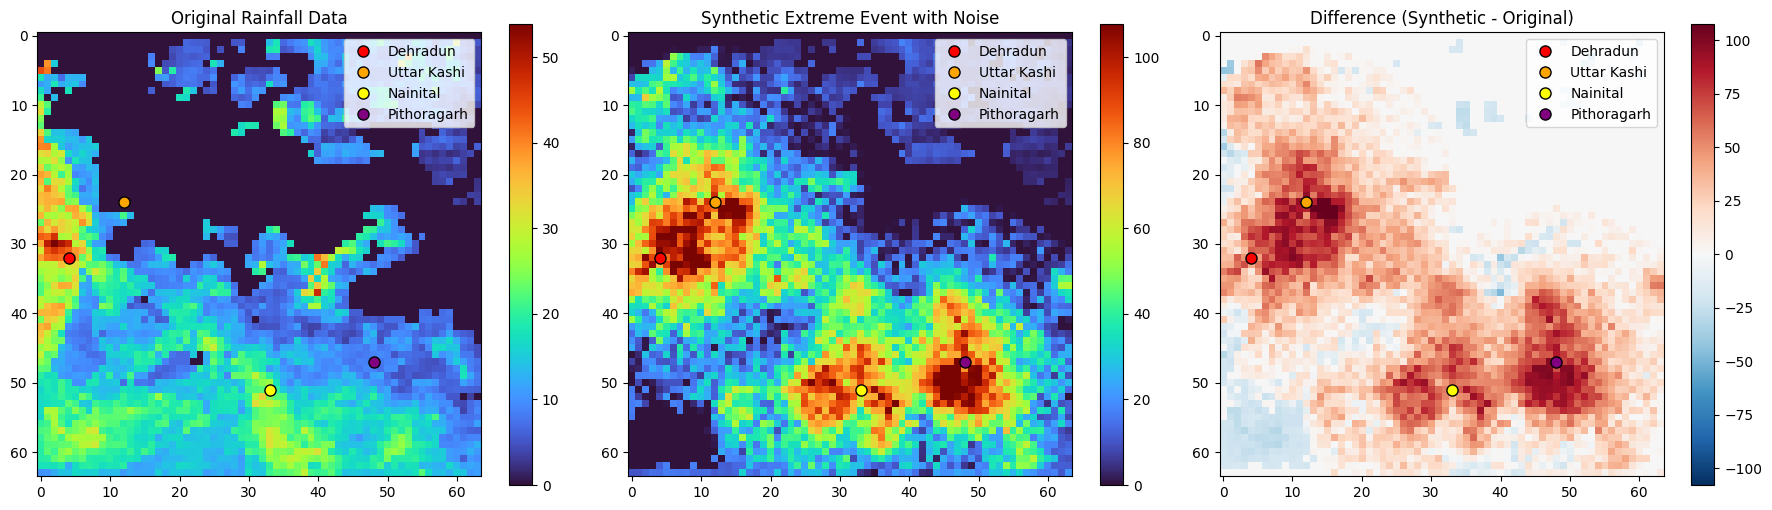


Event Statistics:
Original data - Max: 53.92, Mean: 9.63, Std: 9.38
Synthetic 1 - Max: 107.83, Mean: 28.84, Std: 28.09
Synthetic 2 - Max: 107.83, Mean: 24.79, Std: 28.00


In [5]:
class ExtremeRainfallGenerator:
    def __init__(self, rainfall_raster_path):
        """
        Initialize with base rainfall data
        
        Parameters:
        rainfall_raster_path: path to your rainfall raster file
        """
        self.src = rasterio.open(rainfall_raster_path)
        self.rainfall_data = self.src.read(1)
        self.rainfall_data[np.isnan(self.rainfall_data)] = 0.0
        self.rainfall_data[self.rainfall_data < 0.1] = 0.0
        self.profile = self.src.profile
        
    def extract_extreme_events(self, threshold_percentile=95, min_event_size=10):
        """
        Extract extreme rainfall events from existing data
        
        Parameters:
        threshold_percentile: percentile threshold for extreme events
        min_event_size: minimum contiguous area for an event
        """
        # Calculate threshold
        threshold = np.percentile(self.rainfall_data, threshold_percentile)
        
        # Create binary mask for extreme events
        extreme_mask = self.rainfall_data > threshold
        
        # Label connected components
        labeled_array, num_features = ndimage.label(extreme_mask)
        
        extreme_events = []
        for i in range(1, num_features + 1):
            event_mask = labeled_array == i
            if np.sum(event_mask) >= min_event_size:
                # Extract event properties
                event_indices = np.where(event_mask)
                event_values = self.rainfall_data[event_mask]
                
                event_properties = {
                    'mask': event_mask,
                    'values': event_values,
                    'centroid': self._calculate_centroid(event_indices),
                    'intensity_stats': {
                        'mean': np.mean(event_values),
                        'max': np.max(event_values),
                        'std': np.std(event_values)
                    },
                    'size': np.sum(event_mask)
                }
                extreme_events.append(event_properties)
        
        return extreme_events
    
    def _calculate_centroid(self, indices):
        """Calculate centroid of event from indices"""
        rows, cols = indices
        return np.mean(rows), np.mean(cols)
    
    def _add_multiscale_noise(self, base_event, noise_intensity=0.3, 
                             spatial_correlation=True):
        """
        Add realistic multiscale noise to the rainfall event
        
        Parameters:
        base_event: base synthetic event without noise
        noise_intensity: overall intensity of noise (0-1)
        spatial_correlation: whether to use spatially correlated noise
        """
        rows, cols = base_event.shape
        noisy_event = base_event.copy()
        
        # Only add noise where there's actual rainfall
        rainfall_mask = base_event > 0
        
        if not np.any(rainfall_mask):
            return noisy_event
        
        # Get the intensity range for scaling noise appropriately
        max_intensity = np.max(base_event)
        mean_intensity = np.mean(base_event[rainfall_mask])
        
        if spatial_correlation:
            # Method 1: Spatially correlated noise (more realistic)
            noise = self._generate_correlated_noise(rows, cols, 
                                                  base_correlation=0.7,
                                                  num_scales=4)
        else:
            # Method 2: Simple Gaussian noise
            noise = np.random.normal(0, 1, (rows, cols))
        
        # Scale noise based on local intensity (more variation in intense areas)
        intensity_weights = base_event / (max_intensity + 1e-8)
        
        # Combine different noise types for realism
        final_noise = self._combine_noise_types(noise, rows, cols, 
                                              intensity_weights, rainfall_mask)
        
        # Scale noise to appropriate intensity
        noise_scaling = mean_intensity * noise_intensity
        final_noise = final_noise * noise_scaling
        
        # Apply noise only to rainfall areas
        noisy_event[rainfall_mask] += final_noise[rainfall_mask]
        
        # Ensure no negative values
        noisy_event = np.maximum(noisy_event, 0)
        
        return noisy_event
    
    def _generate_correlated_noise(self, rows, cols, base_correlation=0.7, 
                                 num_scales=4):
        """
        Generate spatially correlated noise using multiscale approach
        """
        noise = np.zeros((rows, cols))
        
        for scale in range(num_scales):
            # Different scales of noise
            scale_factor = 2 ** scale
            small_rows = max(rows // scale_factor, 4)
            small_cols = max(cols // scale_factor, 4)
            
            # Generate base noise at this scale
            scale_noise = np.random.normal(0, 1, (small_rows, small_cols))
            
            # Resize to original dimensions
            if scale_factor > 1:
                scale_noise = ndimage.zoom(scale_noise, scale_factor, order=1)
                # Trim if necessary
                scale_noise = scale_noise[:rows, :cols]
            
            # Weight by scale (larger scales have more influence)
            weight = 1.0 / (scale + 1)
            noise += scale_noise * weight
        
        # Normalize
        if np.std(noise) > 0:
            noise = noise / np.std(noise)
        
        return noise
    
    def _combine_noise_types(self, base_noise, rows, cols, intensity_weights, mask):
        """
        Combine different types of noise for realism
        """
        # 1. Base correlated noise
        final_noise = base_noise.copy()
        
        # 2. Add small-scale turbulent noise
        turbulent_noise = np.random.normal(0, 0.5, (rows, cols))
        # Make it more pronounced in high-intensity areas
        turbulent_noise = turbulent_noise * intensity_weights
        final_noise += turbulent_noise
        
        # 3. Add some random "hot spots" - very localized extreme values
        if np.random.random() > 0.7:  # 30% chance of hot spots
            hot_spot_noise = self._generate_hot_spots(rows, cols, mask)
            final_noise += hot_spot_noise * 2.0  # Stronger effect
        
        # 4. Add gradient noise for mesoscale organization
        gradient_noise = self._generate_gradient_noise(rows, cols)
        final_noise += gradient_noise * 0.3
        
        return final_noise
    
    def _generate_hot_spots(self, rows, cols, mask):
        """
        Generate localized hot spots for extreme variability
        """
        hot_spots = np.zeros((rows, cols))
        num_spots = np.random.randint(1, max(2, np.sum(mask) // 100))
        
        for _ in range(num_spots):
            # Find a random location within the rainfall area
            rainfall_indices = np.where(mask)
            if len(rainfall_indices[0]) > 0:
                idx = np.random.randint(0, len(rainfall_indices[0]))
                center_y, center_x = rainfall_indices[0][idx], rainfall_indices[1][idx]
                
                # Create small Gaussian spot
                y, x = np.ogrid[:rows, :cols]
                distance = np.sqrt((x - center_x)**2 + (y - center_y)**2)
                spot_radius = np.random.uniform(1, 3)
                hot_spot = np.exp(-distance**2 / (2 * spot_radius**2))
                
                # Random intensity
                intensity = np.random.uniform(1.5, 3.0)
                hot_spots += hot_spot * intensity
        
        return hot_spots
    
    def _generate_gradient_noise(self, rows, cols):
        """
        Generate noise with gradient for mesoscale organization
        """
        # Create random gradient direction
        angle = np.random.uniform(0, 2 * np.pi)
        gradient_x = np.cos(angle)
        gradient_y = np.sin(angle)
        
        # Create coordinate grids
        x = np.linspace(-1, 1, cols)
        y = np.linspace(-1, 1, rows)
        X, Y = np.meshgrid(x, y)
        
        # Gradient field
        gradient_field = X * gradient_x + Y * gradient_y
        
        # Modulate with random noise
        random_modulation = np.random.normal(0, 0.5, (rows, cols))
        gradient_noise = gradient_field * random_modulation
        
        return gradient_noise
    
    def _add_boundary_turbulence(self, base_event, turbulence_intensity=0.2):
        """
        Add enhanced turbulence at event boundaries
        """
        turbulent_event = base_event.copy()
        
        # Find boundaries using gradient
        grad_y, grad_x = np.gradient(base_event)
        boundary_strength = np.sqrt(grad_x**2 + grad_y**2)
        
        # Normalize boundary strength
        if np.max(boundary_strength) > 0:
            boundary_strength = boundary_strength / np.max(boundary_strength)
        
        # Create boundary mask
        boundary_mask = boundary_strength > 0.1
        
        if np.any(boundary_mask):
            # Add noise specifically at boundaries
            boundary_noise = np.random.normal(0, turbulence_intensity, base_event.shape)
            boundary_noise = boundary_noise * boundary_strength
            
            mean_intensity = np.mean(base_event[base_event > 0])
            turbulent_event += boundary_noise * mean_intensity
        
        return np.maximum(turbulent_event, 0)
    
    def create_synthetic_event(self, key_area_coords, event_template=None, 
                             intensity_factor=1.5, size_factor=1.0, 
                             blend_with_background=True,
                             noise_intensity=0.3,
                             add_boundary_turbulence=True):
        """
        Create a synthetic extreme rainfall event with realistic noise
        
        Parameters:
        key_area_coords: list of (x, y) coordinates for key areas
        event_template: template event from extract_extreme_events (optional)
        intensity_factor: multiplier for rainfall intensity
        size_factor: multiplier for event size
        blend_with_background: whether to blend with background rainfall
        noise_intensity: intensity of added noise (0-1)
        add_boundary_turbulence: whether to add enhanced turbulence at boundaries
        """
        
        # Convert geographic coordinates to pixel coordinates
        pixel_coords = []
        for coord in key_area_coords.values():
            py, px = self.src.index(coord[0], coord[1])
            pixel_coords.append((px, py))
        
        # Create base synthetic event
        if event_template is None:
            synthetic_event = self._create_default_event(pixel_coords, 
                                                        intensity_factor, 
                                                        size_factor)
        else:
            synthetic_event = self._create_event_from_template(event_template, 
                                                              pixel_coords,
                                                              intensity_factor,
                                                              size_factor)
        
        # Add realistic noise
        if noise_intensity > 0:
            synthetic_event = self._add_multiscale_noise(
                synthetic_event, 
                noise_intensity=noise_intensity,
                spatial_correlation=True
            )
        
        # Add boundary turbulence
        if add_boundary_turbulence:
            synthetic_event = self._add_boundary_turbulence(
                synthetic_event,
                turbulence_intensity=noise_intensity * 0.5
            )
        
        # Blend with background if requested
        if blend_with_background:
            background = self._get_background_rainfall()
            synthetic_event = self._blend_with_background(synthetic_event, background)
        
        return synthetic_event
    
    def _create_default_event(self, pixel_coords, intensity_factor, size_factor):
        """Create a default extreme event pattern"""
        rows, cols = self.rainfall_data.shape
        synthetic_event = np.zeros((rows, cols))
        
        for center_x, center_y in pixel_coords:
            # Create distance grid from center
            y, x = np.ogrid[:rows, :cols]
            distance = np.sqrt((x - center_x)**2 + (y - center_y)**2)
            
            # Define event radius based on size factor
            radius = 20 * size_factor  # base radius in pixels
            
            # Create Gaussian-like rainfall pattern with some initial variation
            event_mask = distance <= radius
            
            # Base Gaussian
            base_intensity = np.exp(-distance**2 / (2 * (radius/3)**2))
            
            # Add some initial waviness to avoid perfect symmetry
            angle = np.arctan2(y - center_y, x - center_x)
            waviness = 1 + 0.2 * np.sin(angle * 3)  # 3-lobed pattern
            base_intensity = base_intensity * waviness
            
            # Scale intensity
            max_intensity = np.percentile(self.rainfall_data, 99) * intensity_factor
            intensity = base_intensity * max_intensity
            
            # Add to synthetic event
            synthetic_event[event_mask] = np.maximum(synthetic_event[event_mask], 
                                                   intensity[event_mask])
        
        return synthetic_event
    
    def _create_event_from_template(self, template, pixel_coords, 
                                  intensity_factor, size_factor):
        """Create event based on extracted template"""
        rows, cols = self.rainfall_data.shape
        synthetic_event = np.zeros((rows, cols))
        
        template_mask = template['mask']
        template_values = template['values'] * intensity_factor
        
        for center_x, center_y in pixel_coords:
            # Get template shape
            template_indices = np.where(template_mask)
            template_center = template['centroid']
            
            # Calculate offset to move template to new location
            offset_y = center_y - template_center[0]
            offset_x = center_x - template_center[1]
            
            # Apply size scaling
            if size_factor != 1.0:
                scaled_template = ndimage.zoom(template_mask.astype(float), 
                                             size_factor)
                # Resize back to original shape
                scaled_template = ndimage.zoom(scaled_template, 
                                             1/size_factor)
                template_mask = scaled_template > 0.5
            
            # Place template at new location
            new_indices = (template_indices[0] + int(offset_y),
                          template_indices[1] + int(offset_x))
            
            # Ensure indices are within bounds
            valid_mask = ((new_indices[0] >= 0) & (new_indices[0] < rows) & 
                         (new_indices[1] >= 0) & (new_indices[1] < cols))
            
            valid_indices = (new_indices[0][valid_mask], 
                           new_indices[1][valid_mask])
            valid_values = template_values[valid_mask]
            
            # Add to synthetic event
            synthetic_event[valid_indices] = np.maximum(synthetic_event[valid_indices], 
                                                      valid_values)
        
        return synthetic_event
    
    def _get_background_rainfall(self):
        """Get background rainfall pattern (non-extreme)"""
        threshold = np.percentile(self.rainfall_data, 80)
        background_mask = self.rainfall_data <= threshold
        background = self.rainfall_data.copy()
        background[~background_mask] = 0
        return background
    
    def _blend_with_background(self, synthetic_event, background):
        """Blend synthetic event with background rainfall"""
        # Simple additive blending
        blended = background + synthetic_event
        
        # Ensure we don't create unrealistic values
        max_realistic = np.max(self.rainfall_data) * 2
        blended = np.clip(blended, 0, max_realistic)
        
        return blended
    
    def save_synthetic_event(self, synthetic_event, output_path):
        """Save synthetic event as GeoTIFF"""
        with rasterio.open(output_path, 'w', **self.profile) as dst:
            dst.write(synthetic_event.astype(self.profile['dtype']), 1)
    
    def visualize_comparison(self, original_data, synthetic_event, 
                           key_area_coords=None, save_path=None):
        """Visualize original data and synthetic event"""
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
        
        # Original data
        im1 = ax1.imshow(original_data, cmap='turbo')
        ax1.set_title('Original Rainfall Data')
        plt.colorbar(im1, ax=ax1)
        
        # Synthetic event
        im2 = ax2.imshow(synthetic_event, cmap='turbo')
        ax2.set_title('Synthetic Extreme Event with Noise')
        plt.colorbar(im2, ax=ax2)
        
        # Difference
        diff = synthetic_event - original_data
        im3 = ax3.imshow(diff, cmap='RdBu_r', vmin=-np.max(np.abs(diff)), 
                        vmax=np.max(np.abs(diff)))
        ax3.set_title('Difference (Synthetic - Original)')
        plt.colorbar(im3, ax=ax3)
        
        # Mark key areas if provided
        colors = ["red", "orange", "yellow", "purple"]
        if key_area_coords:
            for color, (name, coord) in zip(colors, key_area_coords.items()):
                py, px = self.src.index(coord[0], coord[1])
                ax1.plot(px, py, 'ro', markersize=8, markeredgecolor='black', markerfacecolor=f"{color}", label=f"{name}")
                ax2.plot(px, py, 'ro', markersize=8, markeredgecolor='black', markerfacecolor=f"{color}", label=f"{name}")
                ax3.plot(px, py, 'ro', markersize=8, markeredgecolor='black', markerfacecolor=f"{color}", label=f"{name}")
        ax1.legend()
        ax2.legend()
        ax3.legend()
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        
        plt.show()

# Example usage with noise
def main(file_path):
    # Initialize generator
    generator = ExtremeRainfallGenerator(file_path)
    
    # Extract real extreme events for templates
    extreme_events = generator.extract_extreme_events(threshold_percentile=95)
    print(f"Found {len(extreme_events)} extreme events in data")
    
    # Define your key areas (example coordinates)
    key_areas = {
        "Dehradun": (78.04699494260008, 30.31438921393443),
        "Uttar Kashi": (78.44195745611083, 30.727701300923005),
        "Nainital": (79.45378873558052, 29.38500689445674),
        "Pithoragarh": (80.21142992737175, 29.581815794485664)
    }
    
    # Create multiple synthetic events with different noise characteristics
    
    # Event 1: Moderate noise
    synthetic1 = generator.create_synthetic_event(
        key_areas,
        intensity_factor=2.0,
        size_factor=1.1,
        noise_intensity=0.35,  # Moderate noise
        add_boundary_turbulence=True
    )
    
    # Event 2: High noise for more chaotic appearance
    synthetic2 = generator.create_synthetic_event(
        key_areas,
        intensity_factor=2.5,
        size_factor=1.0,
        noise_intensity=0.6,  # High noise
        add_boundary_turbulence=True
    )
    
    # Event 3: Using template with noise
    if extreme_events:
        template_event = extreme_events[0]
        synthetic3 = generator.create_synthetic_event(
            key_areas,
            event_template=template_event,
            intensity_factor=1.8,
            size_factor=1.1,
            noise_intensity=0.4,
            add_boundary_turbulence=True
        )
    
    # Save results
    # generator.save_synthetic_event(synthetic1, 'synthetic_event_moderate_noise.tif')
    # generator.save_synthetic_event(synthetic2, 'synthetic_event_high_noise.tif')
    
    # Visualize comparison
    generator.visualize_comparison(
        generator.rainfall_data,
        synthetic1,
        key_area_coords=key_areas,
        # save_path='noisy_event_comparison.png'
    )
    
    # Print statistics to verify realism
    print("\nEvent Statistics:")
    print(f"Original data - Max: {np.max(generator.rainfall_data):.2f}, "
          f"Mean: {np.mean(generator.rainfall_data):.2f}, "
          f"Std: {np.std(generator.rainfall_data):.2f}")
    
    print(f"Synthetic 1 - Max: {np.max(synthetic1):.2f}, "
          f"Mean: {np.mean(synthetic1):.2f}, "
          f"Std: {np.std(synthetic1):.2f}")
    
    print(f"Synthetic 2 - Max: {np.max(synthetic2):.2f}, "
          f"Mean: {np.mean(synthetic2):.2f}, "
          f"Std: {np.std(synthetic2):.2f}")

if __name__ == "__main__":
    main('../../CHIRPS_daily_Uttarakhand/CHIRPS_daily_2017-08-07.tif')

### Preprocessing data

In [6]:
def make_small_values_zero(data, threshold=1.0):
    new = np.copy(data)
    new[new < threshold] = 0.0
    return new

In [7]:
# def normalize_rainy_pixels(dataset, rain_threshold=0.1):
#     """
#     Normalize rainy pixels to [0,1] based on 99th percentile
#     Non-rainy pixels remain 0
#     """
#     # Create rain mask
#     p99s = []
#     rain_masks = []
#     normalized_dataset = []
#     for data in dataset:
#         rain_mask = data > rain_threshold
        
#         # Calculate normalization value (99th percentile of rainy pixels)
#         if np.any(rain_mask):
#             p99 = np.percentile(data[rain_mask], 99)
#         else:
#             p99 = 1.0  # fallback if no rain
        
#         # Normalize only rainy pixels
#         normalized_data = np.zeros_like(data)
#         normalized_data[rain_mask] = data[rain_mask] / p99
        
#         # Clip anything above 1 (extreme values)
#         normalized_data = np.clip(normalized_data, 0, 1)

#         normalized_dataset.append(normalized_data)
#         p99s.append(p99)
#         rain_masks.append(rain_mask)
    
#     return np.array(normalized_dataset), np.array(rain_masks), np.array(p99s)

# # Apply to both datasets
# chirps_normalized, chirps_masks, chirps_p99s = normalize_rainy_pixels(chirps_dataset)
# era5_normalized, era5_masks, era5_p99s = normalize_rainy_pixels(reprojected_era5_dataset)

# print(f"CHIRPS 99th percentile: {chirps_p99:.4f}")
# print(f"ERA5 99th percentile: {era5_p99:.4f}")
# fig, axs = plt.subplots(1, 2)
# axs[0].plot(chirps_p99s)
# axs[1].plot(era5_p99s)

In [8]:
# i = 1001
# fig, axs = plt.subplots(2, 2, figsize=(12, 7))
# fig_1 = axs[0, 0].imshow(chirps_normalized[i], cmap="turbo")
# divider = make_axes_locatable(axs[0, 0])
# cax = divider.append_axes("right", size="5%", pad=0.05)
# plt.colorbar(fig_1, cax=cax, orientation="vertical", label="Precipitation (mm/d)")

# fig_2 = axs[0, 1].imshow(era5_normalized[i, 2, :], cmap="turbo")
# divider = make_axes_locatable(axs[0, 1])
# cax = divider.append_axes("right", size="5%", pad=0.05)
# plt.colorbar(fig_2, cax=cax, orientation="vertical", label="Precipitation (mm/d)")


# fig_3 = axs[1, 0].imshow(make_small_values_zero(chirps_dataset[i], threshold=2.0), cmap="turbo")
# divider = make_axes_locatable(axs[1, 0])
# cax = divider.append_axes("right", size="5%", pad=0.05)
# plt.colorbar(fig_3, cax=cax, orientation="vertical", label="Precipitation (mm/d)")

# fig_4 = axs[1, 1].imshow(make_small_values_zero(reprojected_era5_dataset[i, 2, :], threshold=0.5), cmap="turbo")
# divider = make_axes_locatable(axs[1, 1])
# cax = divider.append_axes("right", size="5%", pad=0.05)
# plt.colorbar(fig_4, cax=cax, orientation="vertical", label="Precipitation (mm/d)")

# plt.tight_layout()

In [9]:
def detect_clusters_and_filter(image, percent_area_threshold=0.01, density_threshold=0.05):
    """
    Detects connected clusters in a binary image and filters based on
    relative area (percentage of total image) and density threshold.

    Parameters:
        image (ndarray): Input grayscale or binary image
        percent_area_threshold (float): Minimum area fraction of total image (e.g. 0.01 = 1%)
        density_threshold (float): Minimum total cluster density threshold (0–1)

    Returns:
        has_sufficient_density (bool): True if total large-cluster density ≥ threshold
        large_clusters (list): List of dicts with area, bbox, centroid
        image (ndarray): Original image (unchanged)
    """
    if image is None:
        return False, [], None

    # Convert to binary
    _, binary = cv2.threshold(image, 16, 255, cv2.THRESH_BINARY)

    # Find connected components
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary, connectivity=8)

    # Compute total image area
    image_area = image.shape[0] * image.shape[1]

    # Convert percent threshold to absolute pixel area
    area_threshold = percent_area_threshold * image_area

    large_clusters = []
    total_large_cluster_area = 0

    for i in range(1, num_labels):  # Skip background
        area = stats[i, cv2.CC_STAT_AREA]
        if area > area_threshold:
            large_clusters.append({
                'area': area,
                'bbox': stats[i, :4],
                'centroid': centroids[i]
            })
            total_large_cluster_area += area

    # Calculate overall cluster density
    density = total_large_cluster_area / image_area
    has_sufficient_density = density >= density_threshold

    return has_sufficient_density, large_clusters, image

# Example usage for single image
# chirps_dataset[-2000]
# filtered_chirps = []
# filtered_era5 = []
# N = len(reprojected_era5_dataset)
# for chirps, era5 in tqdm(list(zip(chirps_dataset[:N], reprojected_era5_dataset))):
#     has_sufficient_density, _, _ = detect_clusters_and_filter(chirps.astype(np.uint8), area_threshold=10, density_threshold=0.1)
#     if has_sufficient_density:
#         filtered_chirps.append(chirps)
#         filtered_era5.append(era5)

# filtered_chirps = np.array(filtered_chirps)
# filtered_era5 = np.array(filtered_era5)
# print(len(filtered_chirps))
# print(f"Meets density criteria: {result[0]}")
# print(f"Number of large clusters: {len(result[1])}")

In [10]:
# plt.plot(filtered.mean(axis=(1,2)))

In [11]:
# fig, axs = plt.subplots(1, 2, figsize=(12, 7))
# fig_1 = axs[0].imshow(filtered_chirps[1800], cmap="turbo")
# plt.colorbar(fig_1, ax=axs[0])

# fig_2 = axs[1].imshow(filtered_era5[1800, 2], cmap="turbo")
# plt.colorbar(fig_2, ax=axs[1])

Total components found: 25


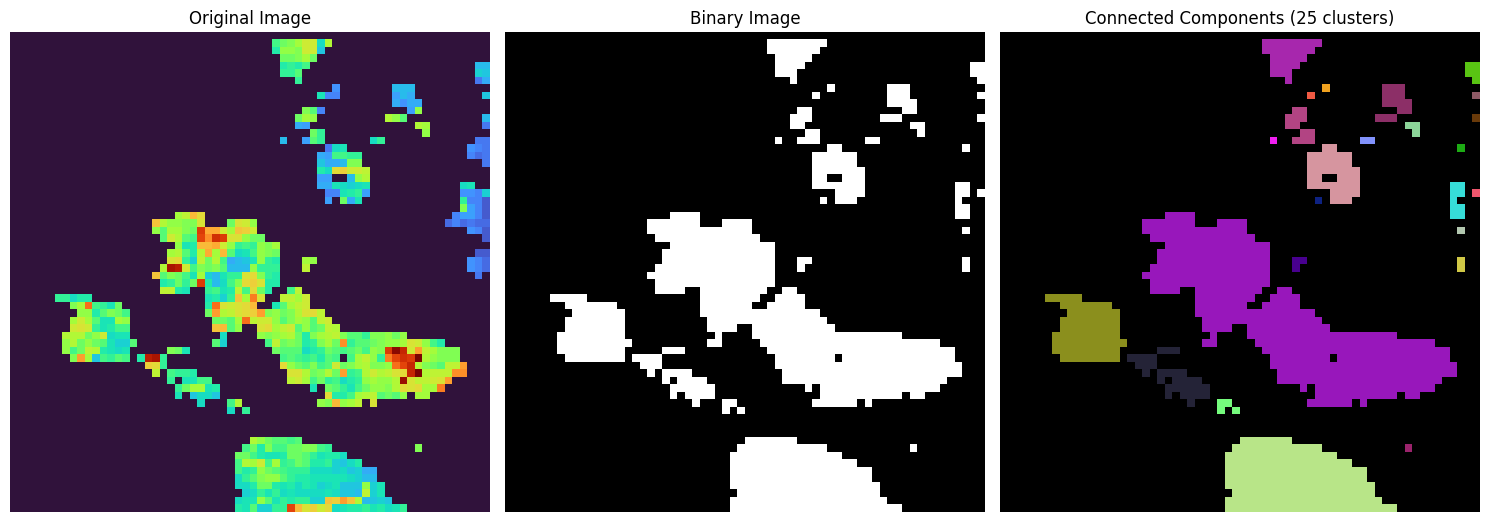

In [ ]:
def visualize_connected_components(image, area_threshold=100):
    # Read and preprocess image
    # image = cv2.imread(image_path)
    # gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Apply threshold
    _, binary = cv2.threshold(image, 8, 255, cv2.THRESH_BINARY)
    
    # Get connected components
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary, connectivity=8)
    
    print(f"Total components found: {num_labels - 1}")  # Subtract 1 for background
    
    # Create a colorful visualization
    height, width = labels.shape
    colored_labels = np.zeros((height, width, 3), dtype=np.uint8)
    
    # Generate random colors for each label (skip background label 0)
    for label in range(1, num_labels):
        # Create random color for each component
        color = np.random.randint(0, 255, 3).tolist()
        colored_labels[labels == label] = color
    
    # Create visualization with bounding boxes
    output_image = image.copy()
    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        if area > area_threshold:
            x, y, w, h = stats[i, :4]
            cx, cy = int(centroids[i][0]), int(centroids[i][1])
            
            # Draw bounding box
            cv2.rectangle(output_image, (x, y), (x + w, y + h), (0, 255, 0), 2)
            
            # Draw centroid
            cv2.circle(output_image, (cx, cy), 4, (0, 0, 255), -1)
            
            # Add label with area
            cv2.putText(output_image, f'{area}', (x, y-10), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)
    
    # Plot results
    fig, axes = plt.subplots(1, 2, figsize=(15, 12), dpi=200)
    
    # Original image
    axes[0].imshow(image, cmap="turbo")
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    
    # # Binary image
    # axes[1].imshow(binary, cmap='gray')
    # axes[1].set_title('Binary Image')
    # axes[1].axis('off')
    
    # Colored components
    axes[1].imshow(colored_labels)
    axes[1].set_title(f'Connected Components ({num_labels-1} clusters)')
    axes[1].axis('off')
    
    # # Bounding boxes
    # axes[1,1].imshow(output_image, cmap="turbo")
    # axes[1,1].set_title('Detected Clusters with Bounding Boxes')
    # axes[1,1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return num_labels, labels, stats, centroids

# Usage
num_labels, labels, stats, centroids = visualize_connected_components(chirps_dataset[-2].astype(np.uint8), area_threshold=100)

In [13]:
def calculate_gradient_features(data):
    """
    Calculate gradient magnitude and direction
    Returns 3 channels: [magnitude, dx, dy]
    """
    # Calculate gradients
    grad_x = cv2.Sobel(data, cv2.CV_64F, 1, 0, ksize=3)
    grad_y = cv2.Sobel(data, cv2.CV_64F, 0, 1, ksize=3)
    
    # Calculate magnitude and direction
    magnitude = np.sqrt(grad_x**2 + grad_y**2)
    
    # Normalize magnitude to [0,1]
    if np.max(magnitude) > 0:
        magnitude = magnitude / np.max(magnitude)
    
    # Normalize dx, dy to [-1,1] for stability
    if np.max(np.abs(grad_x)) > 0:
        grad_x = grad_x / np.max(np.abs(grad_x))
    if np.max(np.abs(grad_y)) > 0:
        grad_y = grad_y / np.max(np.abs(grad_y))
    
    # Stack into multi-channel image
    gradient_features = np.stack([magnitude, grad_x, grad_y])
    
    return gradient_features

# Apply to ERA5 (use the reprojected 64x64 version)
# gradient_images = []
# for image in tqdm(reprojected_era5_dataset[:,2]):
#     era5_precipitation_gradients = calculate_gradient_features(image)
#     gradient_images.append(era5_precipitation_gradients)
# gradient_images = np.array(gradient_images)
# print(f"ERA5 gradients shape: {era5_gradients.shape}")  # Should be (64, 64, 3)

In [14]:
# np.concatenate((reprojected_era5_dataset, gradient_images), axis=1).shape

In [15]:
# plt.imshow(reprojected_era5_dataset[-1,2], cmap="turbo")

In [16]:
# plt.imshow(gradient_images[-1,0])

## Final processing steps

In [18]:
chirps_dataset.shape, reprojected_era5_dataset.shape

((16314, 64, 64), (14435, 5, 64, 64))

In [19]:
# Normalizing
RAINFALL_THRESHOLD = 1.0
normalized_chirps = []
normalized_era5 = []
N = len(reprojected_era5_dataset)
for chirps, era5 in tqdm(list(zip(chirps_dataset[:N], reprojected_era5_dataset)), desc="Normalizing Dataset"):
    chirps = make_small_values_zero(chirps, threshold=RAINFALL_THRESHOLD)
    era5[2] = make_small_values_zero(era5[2], threshold=RAINFALL_THRESHOLD)
    normalized_chirps.append(chirps)
    normalized_era5.append(era5)
    # print(era5.shape)
    # break

# Filtering based on cluster density
filtered_chirps = []
filtered_era5 = []
filtered_dates = []
YEAR_THRESHOLD = 1999
PERCENT_AREA_THRESHOLD = 0.2
for date, chirps, era5 in tqdm(list(zip(era5_dates, normalized_chirps, normalized_era5)), desc="Filtering"):
    has_sufficient_density, _, _ = detect_clusters_and_filter(chirps.astype(np.uint8), percent_area_threshold=PERCENT_AREA_THRESHOLD)
    if has_sufficient_density:
        if date.year < YEAR_THRESHOLD: # Removing data before 1999 | Because they are all blocky and does not match pattern of data after 1999
            continue
        filtered_chirps.append(chirps)
        filtered_era5.append(era5)
        filtered_dates.append(date)

# Calculating ERA5 gradients
# filtered_era5 = np.array(filtered_era5)
# gradient_images = []
# for image in tqdm(filtered_era5[:, 2], desc="Calculating ERA5 gradients"):
#     era5_precipitation_gradients = calculate_gradient_features(image)
#     gradient_images.append(era5_precipitation_gradients)
# gradient_images = np.array(gradient_images)

final_chirps = np.array(filtered_chirps)
final_dates = np.array(filtered_dates)
final_era5 = np.array(filtered_era5)
# final_era5 = np.concatenate((filtered_era5, gradient_images), axis=1)

final_chirps.shape, final_era5.shape

Filtering: 100%|██████████| 14435/14435 [00:00<00:00, 29016.46it/s]


((519, 64, 64), (519, 5, 64, 64))

In [20]:
final_chirps_dict = {}
for date, chirps in zip(final_dates, final_chirps):
    final_chirps_dict[date] = chirps
final_era5_dict = {}
for date, era5 in zip(final_dates, final_era5):
    final_era5_dict[date] = era5

## EDA on filtered data

In [21]:
MONTH_NAMES = np.array(["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])

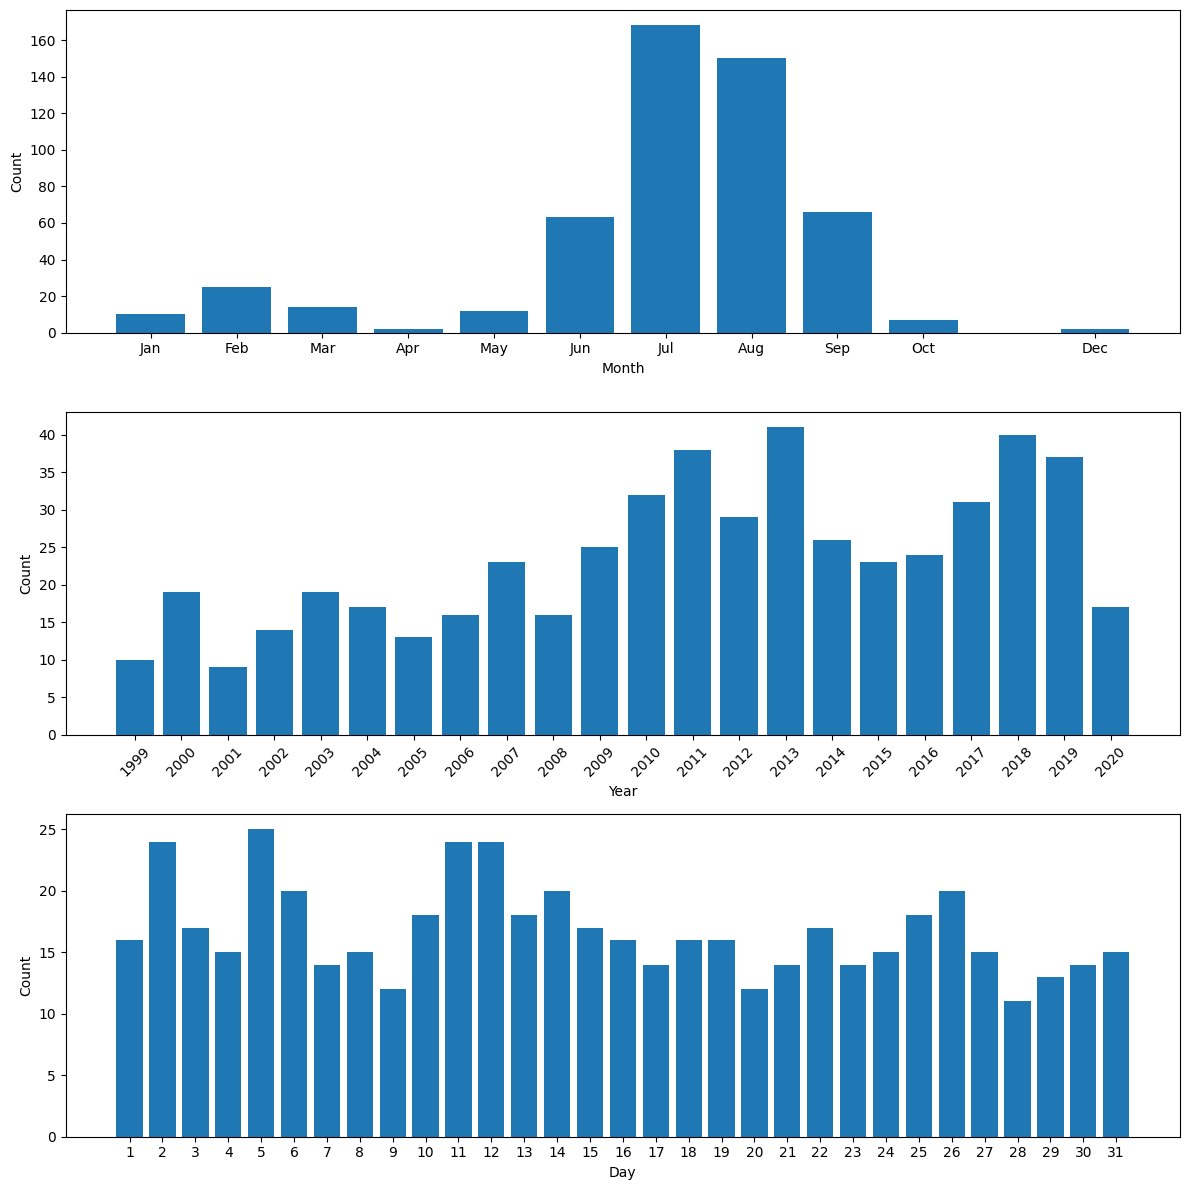

In [22]:
months = []
years = []
days = []
for date in final_dates:
    months.append(date.month)
    years.append(date.year)
    days.append(date.day)
month_nums, month_num_counts = np.unique_counts(months)
year_nums, year_num_counts = np.unique_counts(years)
day_nums, day_num_counts = np.unique_counts(days)

filtered_month_names = MONTH_NAMES[(month_nums-1)] # Getting month names for corresponding mont numbers from data. Subtracting by 1 to make them python index

fig, axs = plt.subplots(3, 1, figsize=(12, 12))
axs[0].bar(month_nums, month_num_counts)
axs[0].set_xlabel("Month")
axs[0].set_ylabel("Count")
axs[0].set_xticks(ticks=month_nums, labels=filtered_month_names);

axs[1].bar(year_nums, year_num_counts)
axs[1].set_xlabel("Year")
axs[1].set_ylabel("Count")
axs[1].set_xticks(ticks=year_nums);
axs[1].tick_params("x", rotation=45)

axs[2].bar(day_nums, day_num_counts)
axs[2].set_xlabel("Day")
axs[2].set_ylabel("Count")
axs[2].set_xticks(ticks=day_nums);
# axs[2].tick_params("x", rotation=45)

plt.tight_layout()

### Using CHIRPS dataset to divide datasets into Normal Rain Days and Extreme Rain Days

In [23]:
THRESHOLD_PERCENTILE = 99
THRESHOLD_PRECIPITATION = np.percentile(final_chirps, q=THRESHOLD_PERCENTILE)
normal_rain_days_chirps = []
normal_rain_days_era5 = []
normal_rain_dates = []
extreme_rain_dates = []
extreme_rain_days_era5 = []
extreme_rain_days_chirps = []
for date, chirps, era5 in zip(final_dates, final_chirps, final_era5):
    if np.all(chirps < THRESHOLD_PRECIPITATION):
        normal_rain_days_chirps.append(chirps)
        normal_rain_days_era5.append(era5)
        normal_rain_dates.append(date)
    else:
        extreme_rain_days_chirps.append(chirps)
        extreme_rain_days_era5.append(era5)
        extreme_rain_dates.append(date)
print(f"Threshold Precipitation = {THRESHOLD_PRECIPITATION:0.4f} mm/d")
normal_rain_dates = np.array(normal_rain_dates)
normal_rain_days_chirps = np.array(normal_rain_days_chirps)
normal_rain_days_era5 = np.array(normal_rain_days_era5)
extreme_rain_days_chirps = np.array(extreme_rain_days_chirps)
extreme_rain_days_era5 = np.array(extreme_rain_days_era5)

Threshold Precipitation = 111.3811 mm/d


In [24]:
# print(f"ERA5")
print(f"Normal Rain days = {normal_rain_days_era5.shape[0]} \nExtreme Rain days = {extreme_rain_days_era5.shape[0]}")
# print(f"Normal Rain days = {normal_rain_days_chirps.shape[0]} \nExtreme Rain days = {extreme_rain_days_chirps.shape[0]}")

Normal Rain days = 283 
Extreme Rain days = 236


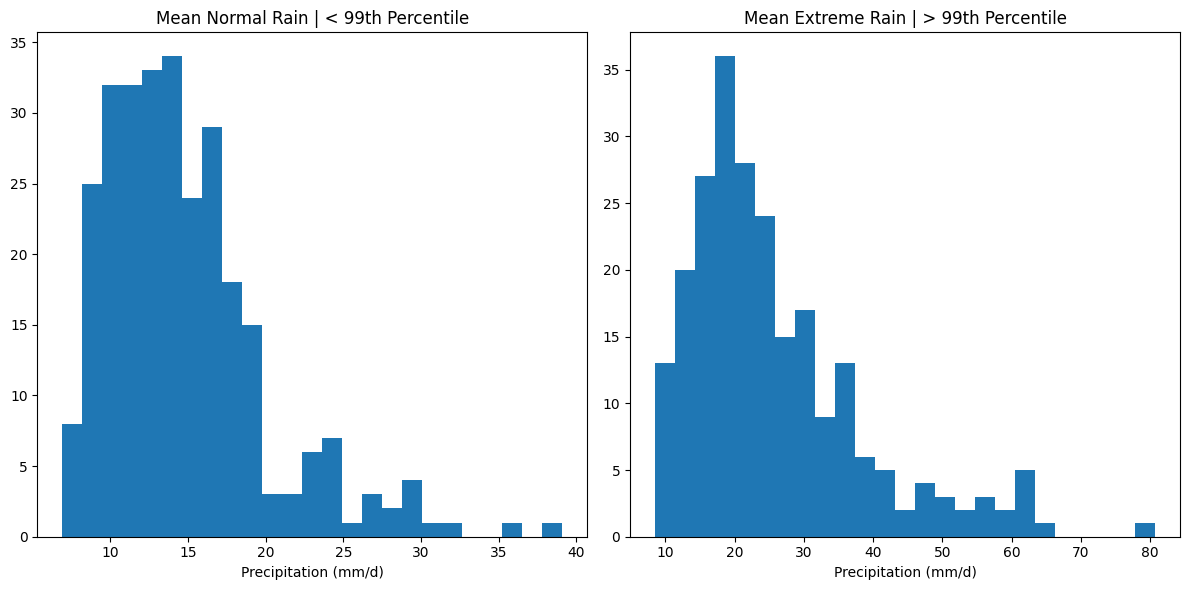

In [25]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].hist(np.mean(normal_rain_days_chirps, axis=(1,2)), bins=25)
axs[0].set_title(f"Mean Normal Rain | < {THRESHOLD_PERCENTILE}th Percentile")
axs[0].set_xlabel("Precipitation (mm/d)")

axs[1].hist(np.mean(extreme_rain_days_chirps, axis=(1,2)), bins=25)
axs[1].set_title(f"Mean Extreme Rain | > {THRESHOLD_PERCENTILE}th Percentile")
axs[1].set_xlabel("Precipitation (mm/d)")
plt.tight_layout()

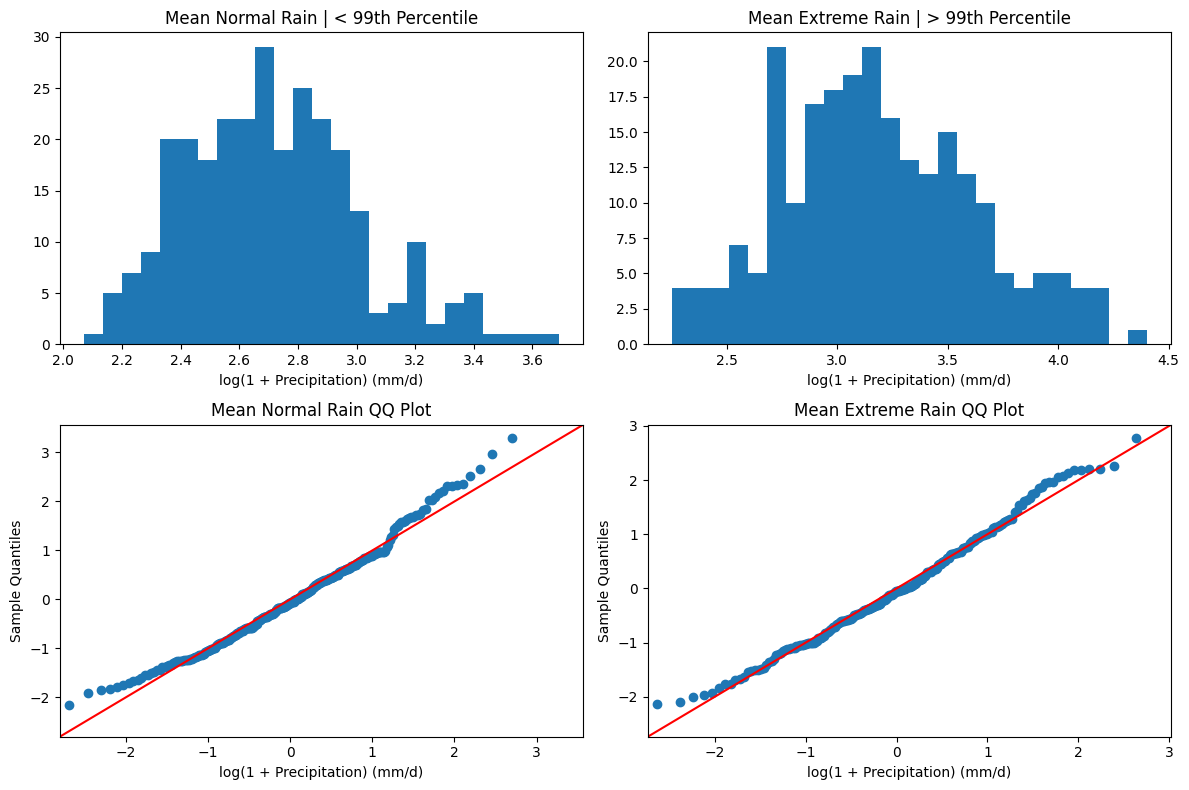

In [26]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs[0, 0].hist(np.log(1 + np.mean(normal_rain_days_chirps, axis=(1,2))), bins=25)
axs[0, 0].set_title(f"Mean Normal Rain | < {THRESHOLD_PERCENTILE}th Percentile")
axs[0, 0].set_xlabel("log(1 + Precipitation) (mm/d)")

axs[0, 1].hist(np.log(1 + np.mean(extreme_rain_days_chirps, axis=(1,2))), bins=25)
axs[0, 1].set_title(f"Mean Extreme Rain | > {THRESHOLD_PERCENTILE}th Percentile")
axs[0, 1].set_xlabel("log(1 + Precipitation) (mm/d)")

sm.qqplot(np.log(1 + np.mean(normal_rain_days_chirps, axis=(1,2))), ax=axs[1, 0], fit=True, line="45")
axs[1, 0].set_title(f"Mean Normal Rain QQ Plot")
axs[1, 0].set_xlabel("log(1 + Precipitation) (mm/d)")

sm.qqplot(np.log(1 + np.mean(extreme_rain_days_chirps, axis=(1,2))), ax=axs[1, 1], fit=True, line="45")
axs[1, 1].set_title(f"Mean Extreme Rain QQ Plot")
axs[1, 1].set_xlabel("log(1 + Precipitation) (mm/d)")
plt.tight_layout()

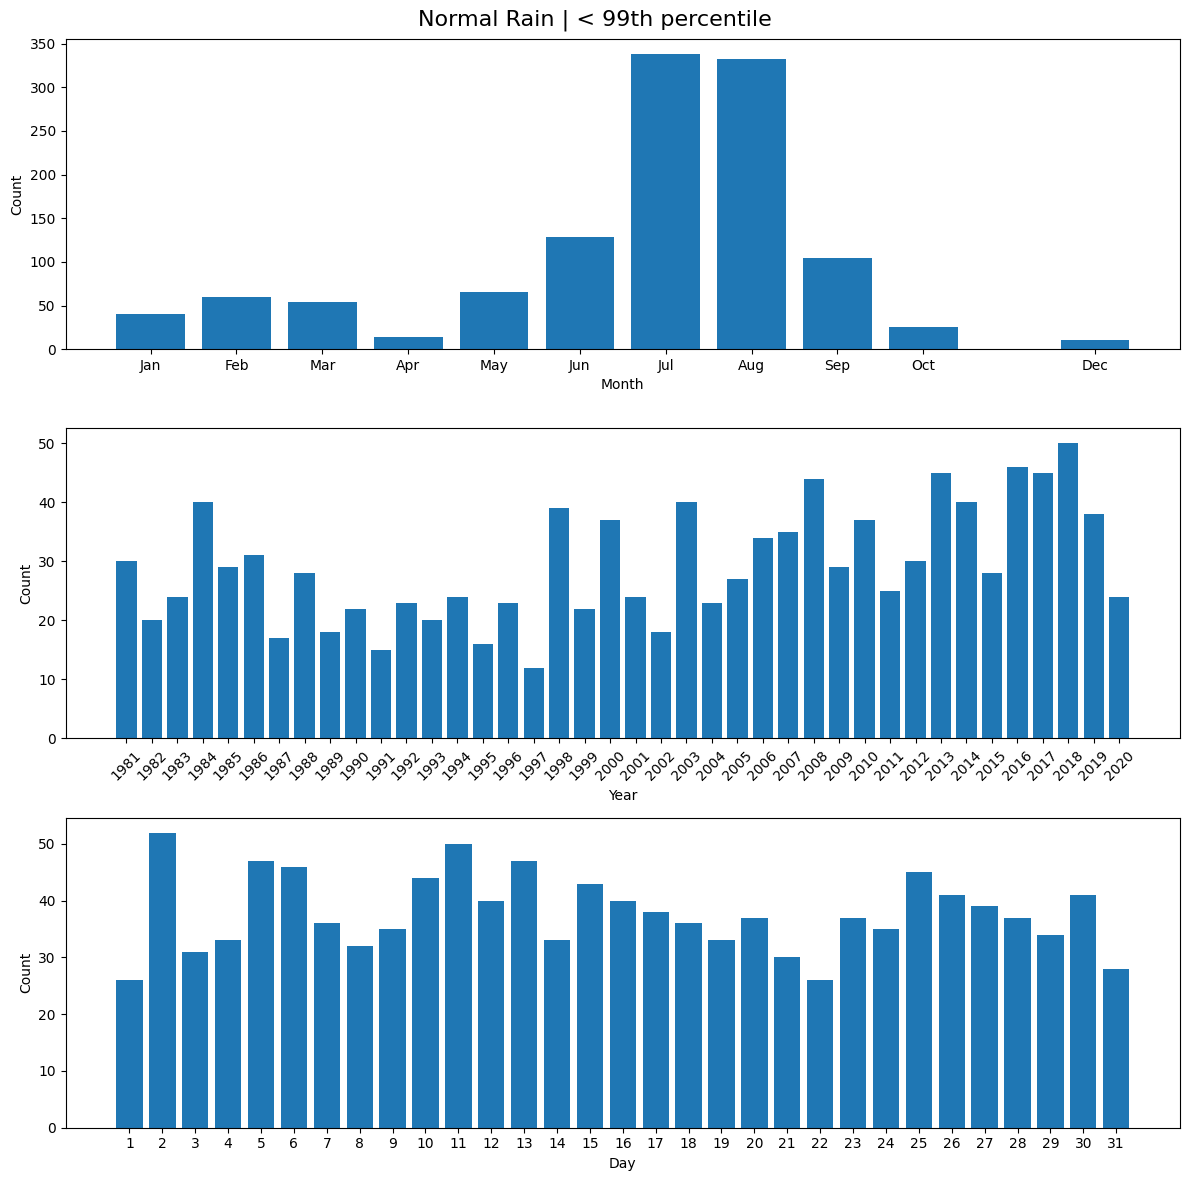

In [26]:
months = []
years = []
days = []
for date in normal_rain_dates:
    months.append(date.month)
    years.append(date.year)
    days.append(date.day)
month_nums, month_num_counts = np.unique_counts(months)
year_nums, year_num_counts = np.unique_counts(years)
day_nums, day_num_counts = np.unique_counts(days)

filtered_month_names = MONTH_NAMES[(month_nums-1)] # Getting month names for corresponding mont numbers from data. Subtracting by 1 to make them python index

fig, axs = plt.subplots(3, 1, figsize=(12, 12))
axs[0].bar(month_nums, month_num_counts)
axs[0].set_xlabel("Month")
axs[0].set_ylabel("Count")
axs[0].set_xticks(ticks=month_nums, labels=filtered_month_names);

axs[1].bar(year_nums, year_num_counts)
axs[1].set_xlabel("Year")
axs[1].set_ylabel("Count")
axs[1].set_xticks(ticks=year_nums);
axs[1].tick_params("x", rotation=45)

axs[2].bar(day_nums, day_num_counts)
axs[2].set_xlabel("Day")
axs[2].set_ylabel("Count")
axs[2].set_xticks(ticks=day_nums);

plt.suptitle(f"Normal Rain | < {THRESHOLD_PERCENTILE}th percentile", fontsize=16)
plt.tight_layout()

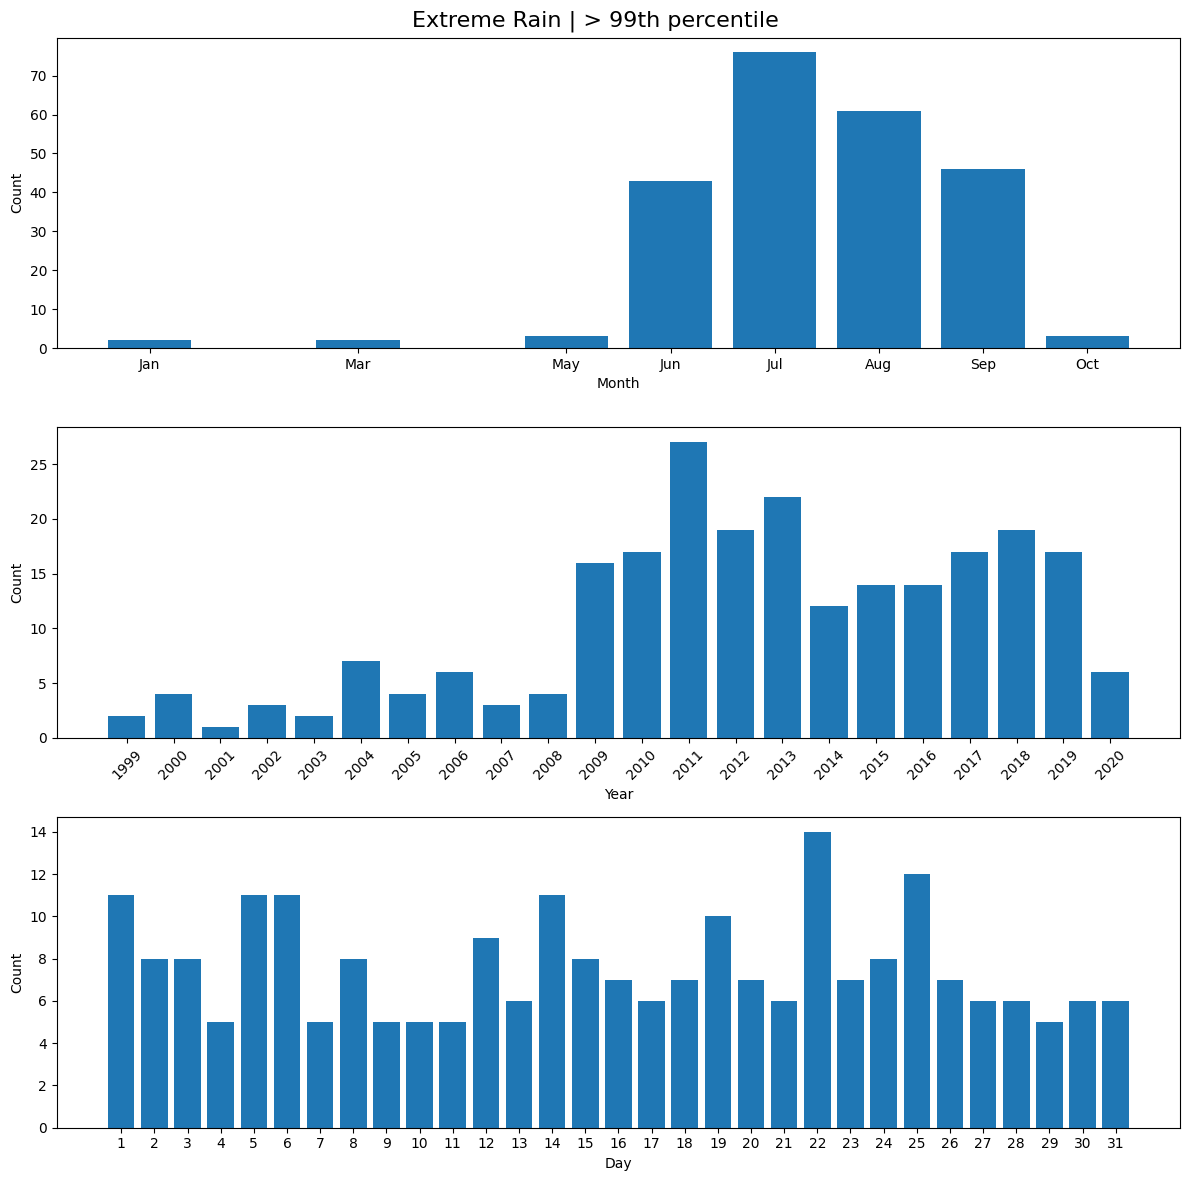

In [27]:
months = []
years = []
days = []
for date in extreme_rain_dates:
    months.append(date.month)
    years.append(date.year)
    days.append(date.day)
month_nums, month_num_counts = np.unique_counts(months)
year_nums, year_num_counts = np.unique_counts(years)
day_nums, day_num_counts = np.unique_counts(days)

filtered_month_names = MONTH_NAMES[(month_nums-1)] # Getting month names for corresponding mont numbers from data. Subtracting by 1 to make them python index

fig, axs = plt.subplots(3, 1, figsize=(12, 12))
axs[0].bar(month_nums, month_num_counts)
axs[0].set_xlabel("Month")
axs[0].set_ylabel("Count")
axs[0].set_xticks(ticks=month_nums, labels=filtered_month_names);

axs[1].bar(year_nums, year_num_counts)
axs[1].set_xlabel("Year")
axs[1].set_ylabel("Count")
axs[1].set_xticks(ticks=year_nums);
axs[1].tick_params("x", rotation=45)

axs[2].bar(day_nums, day_num_counts)
axs[2].set_xlabel("Day")
axs[2].set_ylabel("Count")
axs[2].set_xticks(ticks=day_nums);

plt.suptitle(f"Extreme Rain | > {THRESHOLD_PERCENTILE}th percentile", fontsize=16)
plt.tight_layout()

### Saving data

In [28]:
try:
    os.mkdir("./data")
except FileExistsError:
    print("'data' directory already exists.")

print("Saving Datasets")
with open('./data/final_chirps.pkl', 'wb') as file:
    pickle.dump(final_chirps_dict, file)

with open('./data/final_era5.pkl', 'wb') as file:
    pickle.dump(final_era5_dict, file)

'data' directory already exists.
Saving Datasets


In [ ]:
normal_rain_chirps = {}
normal_rain_era5 = {}
for date, chirps, era5 in zip(normal_rain_dates, normal_rain_days_chirps, normal_rain_days_era5):
    normal_rain_chirps[date] = chirps
    normal_rain_era5[date] = era5

extreme_rain_chirps = {}
extreme_rain_era5 = {}
for date, chirps, era5 in zip(extreme_rain_dates, extreme_rain_days_chirps, extreme_rain_days_era5):
    extreme_rain_chirps[date] = chirps
    extreme_rain_era5[date] = era5

try:
    os.mkdir("./data")
except FileExistsError:
    print("'data' directory already exists.")

print("Saving Normal Rain Days...")
with open('./data/normal_rain_chirps.pkl', 'wb') as file:
    pickle.dump(normal_rain_chirps, file)
with open('./data/normal_rain_era5.pkl', 'wb') as file:
    pickle.dump(normal_rain_era5, file)

print("Saving Extreme Rain Days...")
with open('./data/extreme_rain_chirps.pkl', 'wb') as file:
    pickle.dump(extreme_rain_chirps, file)
with open('./data/extreme_rain_era5.pkl', 'wb') as file:
    pickle.dump(extreme_rain_era5, file)

'data' directory already exists.
Saving Normal Rain Days...
Saving Extreme Rain Days...


In [ ]:
np.log(1 + normal_rain_days_era5[:,2])

array([[[2.637768  , 2.637768  , 2.591922  , ..., 0.        ,
         0.        , 0.        ],
        [2.637768  , 2.637768  , 2.591922  , ..., 0.        ,
         0.        , 0.        ],
        [2.6547956 , 2.6547956 , 2.6154485 , ..., 0.        ,
         0.        , 0.        ],
        ...,
        [2.0562413 , 2.0562413 , 2.1097481 , ..., 0.9196818 ,
         0.9196818 , 0.9196818 ],
        [2.0562413 , 2.0562413 , 2.1097481 , ..., 0.9196818 ,
         0.9196818 , 0.9196818 ],
        [2.0562413 , 2.0562413 , 2.1097481 , ..., 0.9196818 ,
         0.9196818 , 0.9196818 ]],

       [[1.2414533 , 1.2414533 , 1.2541229 , ..., 0.        ,
         0.        , 0.        ],
        [1.2414533 , 1.2414533 , 1.2541229 , ..., 0.        ,
         0.        , 0.        ],
        [1.3102031 , 1.3102031 , 1.329217  , ..., 0.        ,
         0.        , 0.        ],
        ...,
        [1.3145936 , 1.3145936 , 1.3093804 , ..., 1.7054259 ,
         1.7054259 , 1.7054259 ],
        [1.3